In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

np.random.seed(42)

print("All imports successful")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All imports successful
Pandas version: 2.3.3
NumPy version: 2.3.5


In [2]:
# Constants
KCAL_PER_KG = 7700
DAYS = 90
N_USERS = 500

DISEASE_OPTIONS = [
    None,
    "Type 2 Diabetes",
    "Hypertension",
    "High Cholesterol",
    "Hypothyroidism",
    "PCOS",
    "NAFLD",
    "Insulin Resistance",
    "CKD"
]

# BMR calculation using Mifflin St Jeor equation
def calculate_bmr(weight, height, age, gender):
    if gender == "Male":
        return 10 * weight + 6.25 * height - 5 * age + 5
    else:
        return 10 * weight + 6.25 * height - 5 * age - 161

# TDEE from BMR and activity level
def calculate_tdee(bmr, activity_level):
    multipliers = {
        "sedentary":   1.2,
        "light":       1.375,
        "moderate":    1.55,
        "active":      1.725,
        "very_active": 1.9
    }
    return bmr * multipliers[activity_level]

print("Constants and functions defined")

Constants and functions defined


In [3]:
# Core user generator
def generate_user(user_id):
    gender         = np.random.choice(["Male", "Female"])
    age            = np.random.randint(18, 60)
    height         = np.random.uniform(155, 190)
    start_weight   = np.random.uniform(55, 120)
    activity_level = np.random.choice(
        ["sedentary", "light", "moderate", "active", "very_active"]
    )
    goal = np.random.choice(
        ["lose", "gain", "maintain"],
        p=[0.55, 0.25, 0.20]
    )
    disease = np.random.choice(
        DISEASE_OPTIONS,
        p=[0.40, 0.08, 0.08, 0.07, 0.07, 0.07, 0.07, 0.08, 0.08]
    )

    # How consistently the user follows their plan
    adherence = np.random.uniform(0.4, 1.0)

    # How strongly the body resists change over time
    metabolic_adapt_rate = np.random.uniform(0.02, 0.10)

    bmr  = calculate_bmr(start_weight, height, age, gender)
    tdee = calculate_tdee(bmr, activity_level)

    # Daily calorie adjustment based on goal
    if goal == "lose":
        target_daily_delta = np.random.uniform(-600, -200)
    elif goal == "gain":
        target_daily_delta = np.random.uniform(200, 500)
    else:
        target_daily_delta = 0.0

    # Simulate 90 days of weight readings
    true_weight = start_weight
    weight_log  = []

    for day in range(DAYS):
        # Body adapts over time and resists the deficit or surplus
        adaptation_factor = 1 - metabolic_adapt_rate * (day / DAYS)
        adapted_delta     = target_daily_delta * adaptation_factor

        # Some days the user goes off plan
        if np.random.rand() < adherence:
            actual_delta = adapted_delta
        else:
            actual_delta = np.random.uniform(-100, 200)

        # Update true fat weight
        true_weight += actual_delta / KCAL_PER_KG

        # Noise layers
        glycogen_noise    = np.random.normal(0, 0.30)
        sodium_noise      = np.random.normal(0, 0.20)
        measurement_noise = np.random.normal(0, 0.12)

        # Disease conditions cause more water retention noise
        if disease in ["Hypertension", "CKD", "NAFLD"]:
            sodium_noise *= 1.5
        if disease in ["PCOS", "Hypothyroidism"]:
            glycogen_noise *= 1.3

        observed = (
            true_weight
            + glycogen_noise
            + sodium_noise
            + measurement_noise
        )
        weight_log.append(round(observed, 1))

    return {
        "user_id":              user_id,
        "gender":               gender,
        "age":                  age,
        "height_cm":            round(height, 1),
        "start_weight_kg":      round(start_weight, 1),
        "activity_level":       activity_level,
        "goal":                 goal,
        "disease":              disease if disease else "none",
        "adherence":            round(adherence, 2),
        "metabolic_adapt_rate": round(metabolic_adapt_rate, 3),
        "bmr":                  round(bmr, 1),
        "tdee":                 round(tdee, 1),
        "target_daily_delta":   round(target_daily_delta, 1),
        "weight_log":           weight_log
    }

print("User generator function defined")

User generator function defined


In [4]:
# Generate all 500 users
print("Generating synthetic dataset...")

users = [generate_user(i) for i in range(N_USERS)]

print(f"Done. {len(users)} users generated.")

# Quick sanity check on first user
sample = users[0]
print(f"\nSample user:")
print(f"  ID:           {sample['user_id']}")
print(f"  Gender:       {sample['gender']}")
print(f"  Age:          {sample['age']}")
print(f"  Start weight: {sample['start_weight_kg']} kg")
print(f"  Goal:         {sample['goal']}")
print(f"  Disease:      {sample['disease']}")
print(f"  Adherence:    {sample['adherence']}")
print(f"  TDEE:         {sample['tdee']} kcal")
print(f"  First 7 days: {sample['weight_log'][:7]}")

Generating synthetic dataset...
Done. 500 users generated.

Sample user:
  ID:           0
  Gender:       Male
  Age:          46
  Start weight: 105.7 kg
  Goal:         lose
  Disease:      none
  Adherence:    0.43
  TDEE:         3497.3 kcal
  First 7 days: [105.3, 105.4, 105.2, 106.1, 105.2, 105.3, 105.3]


In [5]:
# Flatten weight_log into separate columns for easy use later
rows = []

for user in users:
    base = {k: v for k, v in user.items() if k != "weight_log"}
    for day, weight in enumerate(user["weight_log"]):
        row = base.copy()
        row["day"]    = day + 1
        row["weight"] = weight
        rows.append(row)

df = pd.DataFrame(rows)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (45000, 15)
Columns: ['user_id', 'gender', 'age', 'height_cm', 'start_weight_kg', 'activity_level', 'goal', 'disease', 'adherence', 'metabolic_adapt_rate', 'bmr', 'tdee', 'target_daily_delta', 'day', 'weight']

First 5 rows:


,user_id,gender,age,height_cm,start_weight_kg,activity_level,goal,disease,adherence,metabolic_adapt_rate,bmr,tdee,target_daily_delta,day,weight
0,0,Male,46,161.4,105.7,very_active,lose,none,0.43,0.089,1840.7,3497.3,-359.6,1,105.3
1,0,Male,46,161.4,105.7,very_active,lose,none,0.43,0.089,1840.7,3497.3,-359.6,2,105.4
2,0,Male,46,161.4,105.7,very_active,lose,none,0.43,0.089,1840.7,3497.3,-359.6,3,105.2
3,0,Male,46,161.4,105.7,very_active,lose,none,0.43,0.089,1840.7,3497.3,-359.6,4,106.1
4,0,Male,46,161.4,105.7,very_active,lose,none,0.43,0.089,1840.7,3497.3,-359.6,5,105.2


In [6]:
# Save to CSV
output_path = "../data/synthetic/users_weight_data.csv"
df.to_csv(output_path, index=False)

print(f"Dataset saved to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")

Dataset saved to ../data/synthetic/users_weight_data.csv
File size: 3829.2 KB


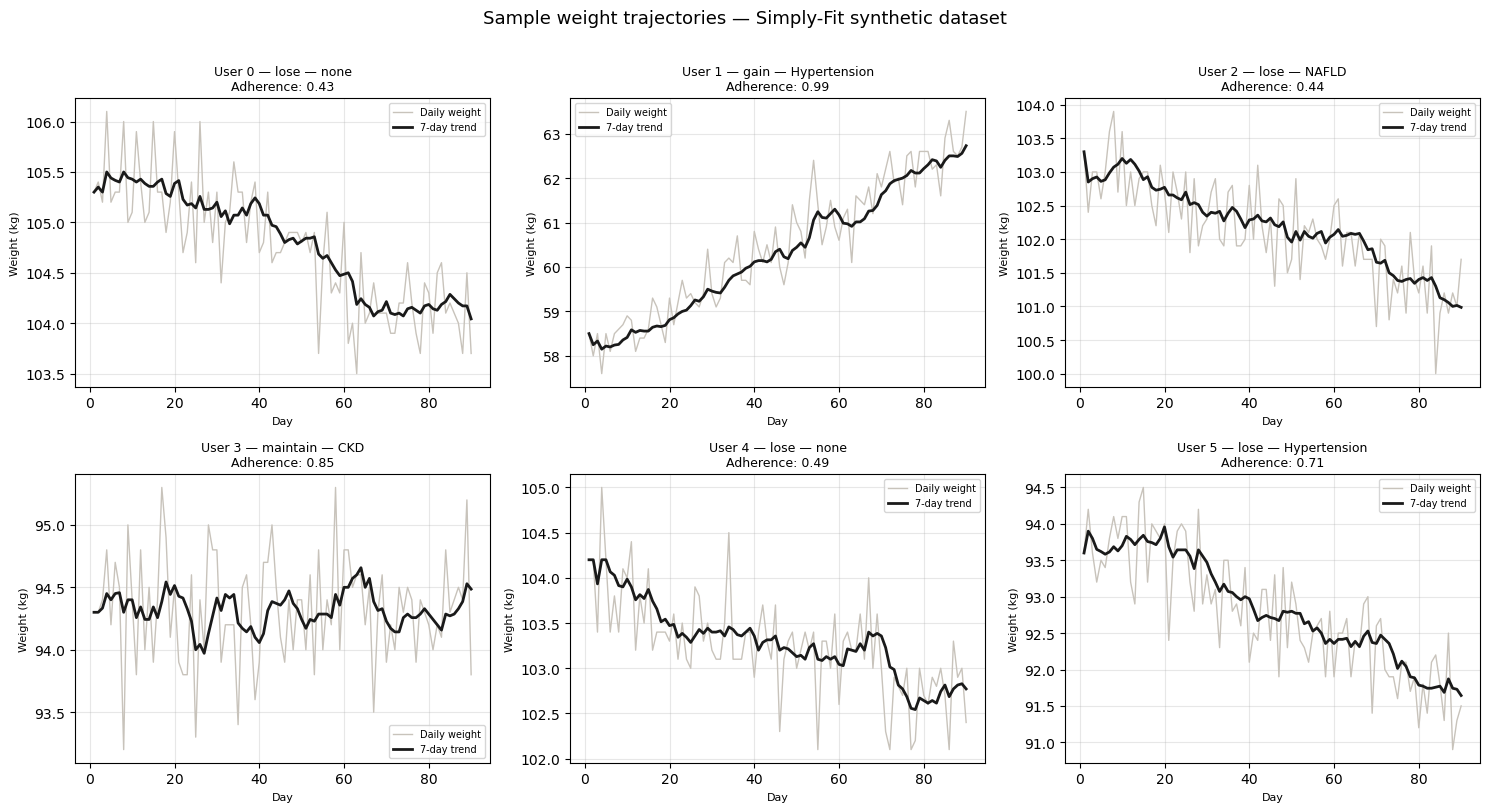

Plot saved


In [7]:
# Visualization — 6 sample users showing different goals and patterns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Sample weight trajectories — Simply-Fit synthetic dataset", 
             fontsize=13, y=1.01)

sample_users = [0, 1, 2, 3, 4, 5]

for idx, user_id in enumerate(sample_users):
    ax = axes[idx // 3][idx % 3]
    
    user_data = df[df["user_id"] == user_id]
    weights   = user_data["weight"].values
    days      = user_data["day"].values
    
    # Rolling average to show true trend
    rolling = pd.Series(weights).rolling(window=7, min_periods=1).mean()
    
    ax.plot(days, weights, color="#C8C3BB", linewidth=1.0, 
            label="Daily weight")
    ax.plot(days, rolling, color="#1A1A1A", linewidth=2.0, 
            label="7-day trend")
    
    user_info = users[user_id]
    ax.set_title(
        f"User {user_id} — {user_info['goal']} — {user_info['disease']}\n"
        f"Adherence: {user_info['adherence']}",
        fontsize=9
    )
    ax.set_xlabel("Day", fontsize=8)
    ax.set_ylabel("Weight (kg)", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/synthetic/sample_trajectories.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

In [9]:
# Dataset summary statistics
print("=" * 50)
print("SIMPLY-FIT SYNTHETIC DATASET SUMMARY")
print("=" * 50)

print(f"\nTotal records:  {len(df):,}")
print(f"Total users:    {df['user_id'].nunique()}")
print(f"Days per user:  {df['day'].max()}")

print(f"\nGoal distribution:")
goal_counts = df.groupby("goal")["user_id"].nunique()
for goal, count in goal_counts.items():
    print(f"  {goal:10s}: {count} users")

print(f"\nDisease distribution:")
disease_counts = df.groupby("disease")["user_id"].nunique()
for disease, count in disease_counts.items():
    print(f"  {disease:30s}: {count} users")

print(f"\nGender distribution:")
gender_counts = df.groupby("gender")["user_id"].nunique()
for gender, count in gender_counts.items():
    print(f"  {gender:10s}: {count} users")

print(f"\nWeight range across all users:")
print(f"  Min: {df['weight'].min()} kg")
print(f"  Max: {df['weight'].max()} kg")
print(f"  Mean: {df['weight'].mean():.1f} kg")

print(f"\nAdherence range:")
print(f"  Min: {df['adherence'].min()}")
print(f"  Max: {df['adherence'].max()}")
print(f"  Mean: {df['adherence'].mean():.2f}")

print("\nDataset is ready for ML pipeline.")

SIMPLY-FIT SYNTHETIC DATASET SUMMARY

Total records:  45,000
Total users:    500
Days per user:  90

Goal distribution:
  gain      : 137 users
  lose      : 262 users
  maintain  : 101 users

Disease distribution:
  CKD                           : 38 users
  High Cholesterol              : 40 users
  Hypertension                  : 47 users
  Hypothyroidism                : 29 users
  Insulin Resistance            : 44 users
  NAFLD                         : 31 users
  PCOS                          : 28 users
  Type 2 Diabetes               : 43 users
  none                          : 200 users

Gender distribution:
  Female    : 246 users
  Male      : 254 users

Weight range across all users:
  Min: 49.7 kg
  Max: 123.9 kg
  Mean: 87.6 kg

Adherence range:
  Min: 0.4
  Max: 1.0
  Mean: 0.70

Dataset is ready for ML pipeline.
